# MNIST digit recognition with TensorFlow and Keras

Most code from Deep Learning with Python, Second Edition - François Chollet (2021).

The "OLD VERSION" commented code refers to the (deprecated) version used in the first edition of the book.

TODO: reproducibility

## Dataset

### Load

In [1]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [2]:
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [3]:
set([type(train_images), type(train_labels), type(test_images), type(test_labels)])

{numpy.ndarray}

### Prepare

In [4]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [5]:
sorted(set(test_labels))

[np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)]

In [6]:
## OLD VERSION (needed)
#from keras.utils import to_categorical
#train_labels = to_categorical(train_labels)
#test_labels = to_categorical(test_labels)

In [7]:
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 784), (60000,), (10000, 784), (10000,))

## Model

### Build (architecture)

In [8]:
## OLD VERSION (works too)
#from keras import models
#from keras import layers
#
#model = models.Sequential()
#model.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
#model.add(layers.Dense(10, activation='softmax'))

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

### Compile

In [10]:
from tensorflow.keras import optimizers

In [11]:
optimizer = optimizers.RMSprop(learning_rate=1e-3)

In [12]:
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

TODO: WARNING:tensorflow:TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.

### Training loop (fit)

In [13]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9235 - loss: 0.2675
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9683 - loss: 0.1085
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9789 - loss: 0.0712
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9848 - loss: 0.0517
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9883 - loss: 0.0391


## Results

### Predictions

In [14]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([1.8102349e-07, 1.6022781e-07, 5.2626881e-05, 1.1615489e-04,
       7.7760513e-11, 9.5503049e-07, 3.8391297e-11, 9.9981314e-01,
       1.7636568e-06, 1.4930616e-05], dtype=float32)

In [15]:
predictions[0].argmax()

np.int64(7)

### Evaluation (accuracy)

In [16]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc:.5%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9796 - loss: 0.0642
test_acc: 97.96000%


### Show

In [17]:
digit = train_images[4]
digit = digit.reshape(28, 28)

In [18]:
## OLD VERSION (fix, for some reason)
#import os
#os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [19]:
import matplotlib.pyplot as plt

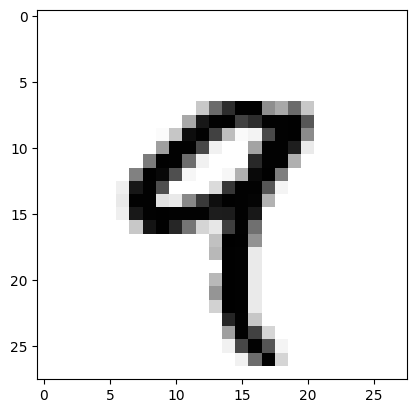

In [20]:
plt.imshow(digit, cmap=plt.cm.binary)

Plot wrongly labeled digits in test

In [21]:
import numpy as np

In [22]:
pred = np.argmax(model.predict(test_images), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [23]:
## OLD VERSION
#real = np.argmax(test_labels, axis=1)

real = test_labels.astype(np.int64)

In [24]:
neqs = (pred != real)
neqs = np.where(neqs)[0]
len(neqs)

204

In [25]:
nrows, ncols = 12, 10

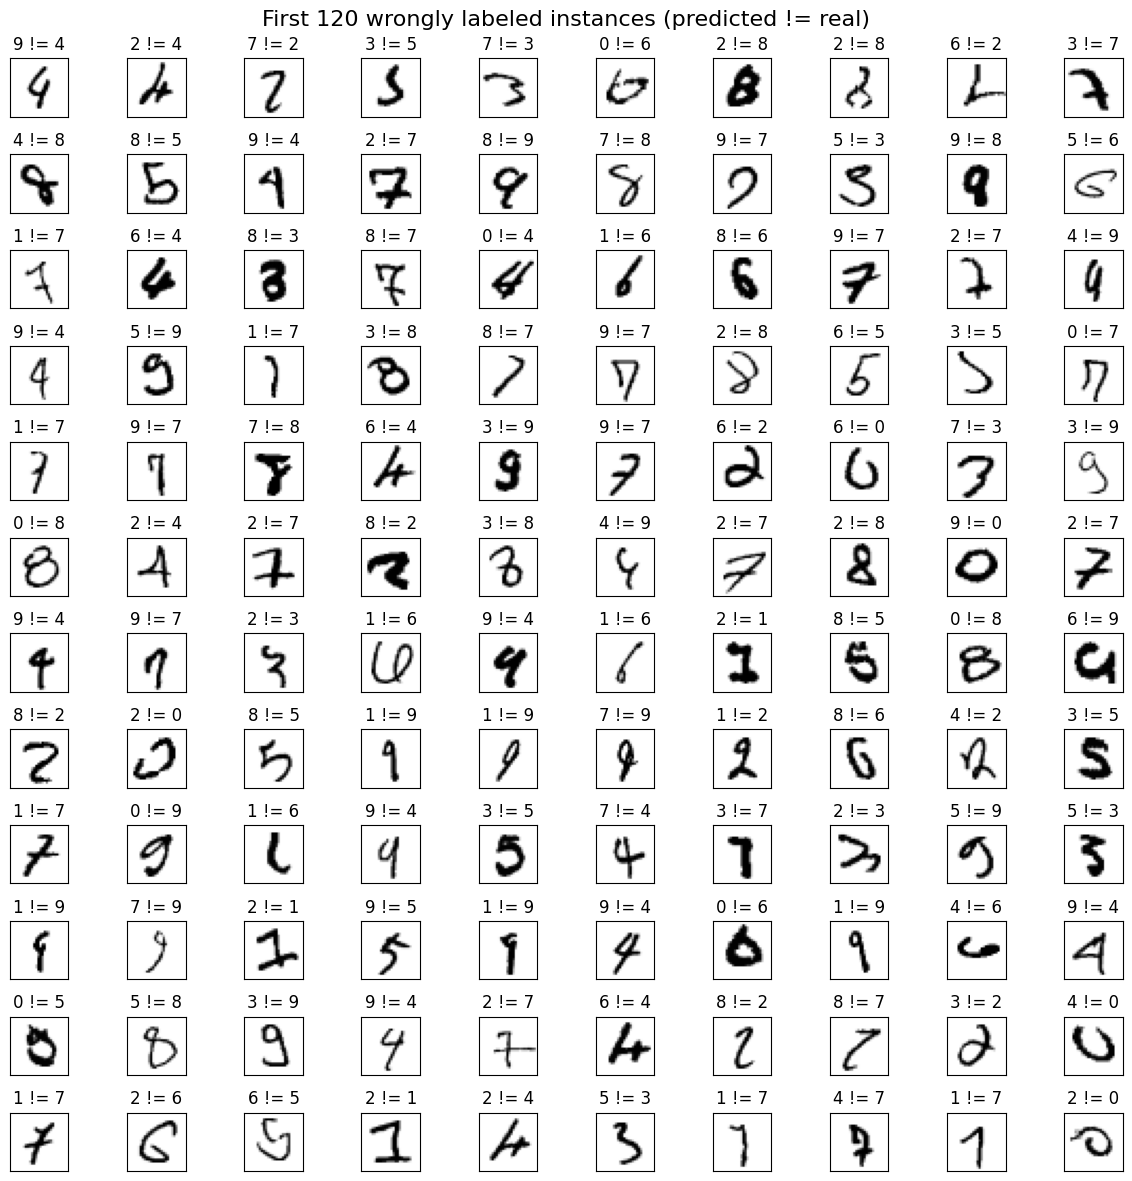

In [26]:
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 12))
axs = axs.flatten()

for i, ax in enumerate(axs):
    idx = neqs[i]
    ax.set_title(f"{pred[idx]} != {real[idx]}")
    digit = test_images[idx]
    digit = digit.reshape(28, 28)
    ax.imshow(digit, cmap=plt.cm.binary)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f"First {nrows * ncols} wrongly labeled instances (predicted != real)", fontsize=16)
fig.tight_layout()